Loading the dataset: CIFAR-10

We will use the CIFAR-10 dataset for training and testing (https://www.cs.toronto.edu/~kriz/cifar.html).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Visualize the data

In [3]:
#print(x_train.shape)

num_classes = 10

#fig = plt.figure(figsize=(10*1/2.54, 10*1/2.54))

#for idx_class in range(num_classes):

  #all_idx = np.where(y_train.flatten() == idx_class)[0]

  # random selection of 10 image of each category
  #rand_idx = np.random.choice(all_idx, size=10, replace=False)
  #selected = x_train[rand_idx]

  #plt.figure(figsize=(10, 10))

  #for i in range(10):
  #  plt.subplot(1, 10, i+1)
  #  plt.imshow(selected[i])
  #  plt.tight_layout()

  #plt.show()

Data normalization

In [4]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


Prepare the labels

In [5]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


Define the first model

In [6]:
input_shape = (32, 32, 3)

model1 = Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Conv2D(32, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),

        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Conv2D(64, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),

        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Dropout(0.25),

        layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Conv2D(128, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),

        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Dropout(0.25),

        # fully connected
        layers.Flatten(),

        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),

        layers.Dropout(0.25),

        layers.Dense(num_classes, activation="softmax")
    ]
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)


Compile the model

In [7]:
import time

#my_SGD = keras.optimizers.SGD(learning_rate=0.001)
#my_Adam = keras.optimizers.Adam(learning_rate=0.005)

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

start = time.time()
history = model1.fit(x_train, y_train, batch_size=512, epochs=50, validation_split=0.1)
end = time.time()

total_time = end - start
print("Training time:", total_time, "seconds")

epochs = len(history.history['loss'])
avg_time = total_time / epochs
print("Average time per epoch:", avg_time, "seconds")

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 209ms/step - accuracy: 0.1985 - loss: 2.6200 - val_accuracy: 0.3890 - val_loss: 1.8516
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.3880 - loss: 1.8553 - val_accuracy: 0.4726 - val_loss: 1.6297
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4597 - loss: 1.6515 - val_accuracy: 0.5132 - val_loss: 1.4958
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5168 - loss: 1.5082 - val_accuracy: 0.5816 - val_loss: 1.3843
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5590 - loss: 1.4043 - val_accuracy: 0.6096 - val_loss: 1.3025
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.5931 - loss: 1.3249 - val_accuracy: 0.6442 - val_loss: 1.1941
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6130 - loss: 1.2667 - val_accuracy: 0.6610 - val_loss: 1.1615
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6349 - loss: 1.2237 - val_accuracy: 0.6742 -

In [8]:
print(history.history.keys())

print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

print("Train loss:", history.history["loss"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.8350222110748291
Validation accuracy: 0.8173999786376953
Train loss: 0.7783346176147461
Validation loss: 0.8450652360916138


Evaluate the model

Test accuracy: 0.8091999888420105
Test loss: 0.8759462833404541
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


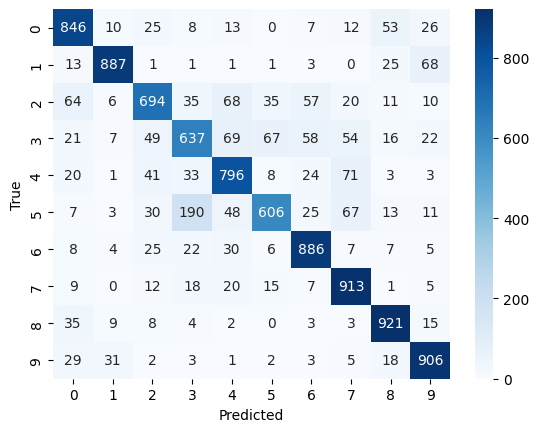

In [9]:
score = model1.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", score[1])
print("Test loss:", score[0])

y_test_pred_prob = model1.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(y_test.argmax(axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Save the model to file#

In [11]:
import os

#print("Working directory:", os.getcwd())
#print("Files here:", os.listdir())

# save the trained model
model1.save("cifar10.model_11_bianca.keras")